In [2]:
import os
os.chdir('../')
%pwd

'/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer'

In [24]:
import gc
import torch
gc.collect()
torch.mps.empty_cache()

In [3]:
from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class VizConfig:
    root_dir: Path
    dense_embd: Path
    local_data: Path
    outwithin:Path
    out:Path

In [4]:
from src.task2 import logger
from src.task2.constants import *
from src.task2.utils.common import read_yaml, create_directories

In [5]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])


    
    def get_viz_config(self) -> VizConfig:
        config = self.config.viz

        create_directories([config.root_dir])

        viz_config = VizConfig(
            root_dir=Path(config.root_dir),
            dense_embd=Path(config.Dense_embedding),
            local_data=Path(config.local_data_file),
            outwithin= Path(config.OUTPUT_within),
            out=Path(config.OUTPUT)
            
            
        )

        return viz_config

In [ ]:
import os
import torch
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.gridspec as gridspec
import json

In [ ]:
class CrossDatasetRetrival:
    def __init__(self,config:VizConfig):
        self.config=config
        with open('annotations.json', 'r') as f:
            master_annotations = json.load(f)
        self.label_1=input("Provide Dataset 1 Label name (e.g: Liver chunk 0):")
        embed1= input("Dense Embeddings 1| What is the name of file? (e.g., dense.pt): ")
        logger.info(f"{embed1}.... Loaded")
        emfile1=os.path.join(self.config.dense_embd,embed1)
        self.emb1 = torch.load(emfile1).numpy()
        localfile1= input("Local File Input 1| What is the name of file? (e.g., liver.npy): ")
        logger.info(f"{localfile1}.... Loaded")
        lf1=os.path.join(self.config.local_data,localfile1)
        self.raw1 = np.load(lf1)
        box_1=input('Enter Dataset 1 annotation name (e.g., ls0, ls1, hs1, hs0, ps1): ')
        self.mito_boxes_ds1 = master_annotations[box_1]

        self.label_2=input("Provide Dataset 2 label name|(e.g: pancreas chunk 0):")
        embed2= input("Dense Embeddings 2| What is the name of file? (e.g., dense.pt): ")
        logger.info(f"{embed2}.... Loaded")
        emfile2=os.path.join(self.config.dense_embd,embed2)
        self.emb2 = torch.load(emfile2).numpy()
        localfile2= input("Local File Input 2| What is the name of file? (e.g., liver.npy): ")
        logger.info(f"{localfile2}.... Loaded")
        lf2=os.path.join(self.config.local_data,localfile2)
        self.raw2 = np.load(lf2)
        box_2=input('Enter Dataset 2 annotation name (e.g., ls0, ls1, hs1, hs0, ps1): ')
        self.mito_boxes_ds2 = master_annotations[box_2]

        self.c1, self.z1, self.h1, self.w1 = self.emb1.shape
        self.c2, self.z2, self.h2, self.w2 = self.emb2.shape

        self.flat1 = normalize(self.emb1.reshape(self.c1, -1).T, norm='l2')
        self.flat2 = normalize(self.emb2.reshape(self.c2, -1).T, norm='l2')

        logger.info(
            f'[{self.label_1}] embeddings: {self.emb1.shape} | voxels: {self.flat1.shape}\n'
            f'[{self.label_2}] embeddings: {self.emb2.shape} | voxels: {self.flat2.shape}\n'
        )
    
    def mMD(self):
        n_samples= input("Input Number of samples(e.g 5000,10000):")
        idx1 = np.random.choice(len(self.flat1), n_samples, replace=False)
        idx2 = np.random.choice(len(self.flat2), n_samples, replace=False)
        X = self.flat1[idx1]
        Y = self.flat2[idx2]
        dists = np.sum((X[:100, None] - Y[None, :100]) ** 2, axis=-1)
        sigma = np.median(dists) + 1e-8
        def rbf(A, B):
            d = np.sum((A[:, None] - B[None]) ** 2, axis=-1)
            return np.exp(-d / (2 * sigma))
        mmd=float(rbf(X, X).mean() + rbf(Y, Y).mean() - 2 * rbf(X, Y).mean())
        logger.info(f'MMD: {mmd}')

    def _align(self, query_vec, gallery):
        mu1  = self.flat1.mean(axis=0, keepdims=True)
        std1 = self.flat1.std(axis=0,  keepdims=True) + 1e-8
        mu2  = self.flat2.mean(axis=0, keepdims=True)
        std2 = self.flat2.std(axis=0,  keepdims=True) + 1e-8

        q_aligned = normalize((query_vec - mu1) / std1, norm='l2')
        g_aligned = normalize((gallery   - mu2) / std2, norm='l2')

        return q_aligned, g_aligned

    def _get_query_vector(self,dataset, z, y_min, y_max, x_min, x_max):
        emb = self.emb1 if dataset == 1 else self.emb2
        roi = emb[:, z, y_min:y_max, x_min:x_max]
        vec = roi.mean(axis=(1, 2))
        vec = vec / (np.linalg.norm(vec) + 1e-8)
        return vec.reshape(1, -1)

    def _compute_cross_heatmap(self,query_vec, use_alignment=True):
        if use_alignment:
            q, gallery = self._align(query_vec, self.flat2)
        else:
            q, gallery = normalize(query_vec, norm='l2'), self.flat2

        sim = (gallery @ q.T).squeeze()
        return sim.reshape(self.z2, self.h2, self.w2)

    def _project_pca(self,vecs_list, use_alignment):
        if use_alignment:
            mu1  = self.flat1.mean(0); std1 = self.flat1.std(0) + 1e-8
            mu2  = self.flat2.mean(0); std2 = self.flat2.std(0) + 1e-8
            aligned = []
            for i, v in enumerate(vecs_list):
                mu  = mu1  if i % 2 == 0 else mu2
                std = std1 if i % 2 == 0 else std2
                aligned.append(normalize((v - mu) / std, norm='l2'))
            vecs_list = aligned

        all_vecs = np.vstack(vecs_list)
        pca      = PCA(n_components=2)
        proj     = pca.fit_transform(all_vecs)
        var      = pca.explained_variance_ratio_

        sizes   = [len(v) for v in vecs_list]
        splits  = np.cumsum(sizes[:-1])
        parts   = np.split(proj, splits)
        return parts, var
    
    def plot_embedding_space(self,
        n_background=1500,
        use_alignment=True):

        idx1 = np.random.choice(len(self.flat1), n_background, replace=False)
        idx2 = np.random.choice(len(self.flat2), n_background, replace=False)
        bg1  = self.flat1[idx1]
        bg2  = self.flat2[idx2]

        mito1 = np.vstack([
            self._get_query_vector(1, b['z'], b['y_min'], b['y_max'],
                                    b['x_min'], b['x_max'])
            for b in self.mito_boxes_ds1
        ])
        mito2 = np.vstack([
            self._get_query_vector(2, b['z'], b['y_min'], b['y_max'],
                                    b['x_min'], b['x_max'])
            for b in self.mito_boxes_ds2
        ])

        (p_bg1, p_bg2, p_m1, p_m2), var = self._project_pca(
            [bg1, bg2, mito1, mito2], use_alignment
        )

        idx1r = np.random.choice(len(self.flat1), n_background, replace=False)
        idx2r = np.random.choice(len(self.flat2), n_background, replace=False)
        raw_proj = PCA(n_components=2).fit_transform(
            np.vstack([self.flat1[idx1r], self.flat2[idx2r]])
        )
        rp_bg1 = raw_proj[:n_background]
        rp_bg2 = raw_proj[n_background:]

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.patch.set_facecolor('#0e1410')

        for ax_idx, ax in enumerate(axes):
            ax.set_facecolor('#0e1410')
            if ax_idx == 0:
                ax.scatter(rp_bg1[:,0], rp_bg1[:,1],
                            c='#185FA5', alpha=0.25, s=4, label=self.label_1)
                ax.scatter(rp_bg2[:,0], rp_bg2[:,1],
                            c='#D85A30', alpha=0.25, s=4, label=self.label_2)
                ax.set_title('PCA — raw embeddings',
                                color='#e8f5ec', fontsize=11, pad=8)
                ax.set_xlabel('PC1', color='#6b8f72', fontsize=9)
                ax.set_ylabel('PC2', color='#6b8f72', fontsize=9)
            else:
                ax.scatter(p_bg1[:,0], p_bg1[:,1],
                            c='#185FA5', alpha=0.25, s=4, label=self.label_1)
                ax.scatter(p_bg2[:,0], p_bg2[:,1],
                            c='#D85A30', alpha=0.25, s=4, label=self.label_2)
                ax.scatter(p_m1[:,0],  p_m1[:,1],
                            c='#4ade80', s=80, marker='*', zorder=5,
                            label=f'{self.label_1} mito')
                ax.scatter(p_m2[:,0],  p_m2[:,1],
                            c='#f472b6', s=80, marker='*', zorder=5,
                            label=f'{self.label_2} mito')
                for m1v, m2v in zip(p_m1, p_m2):
                    ax.plot([m1v[0], m2v[0]], [m1v[1], m2v[1]],
                            color='white', alpha=0.2, linewidth=0.8,
                            linestyle='--')
                ax.set_title('PCA — after Z-score alignment',
                                color='#e8f5ec', fontsize=11, pad=8)
                ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var)',
                                color='#6b8f72', fontsize=9)
                ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var)',
                                color='#6b8f72', fontsize=9)

            ax.tick_params(colors='#6b8f72', labelsize=8)
            for sp in ax.spines.values():
                sp.set_edgecolor('#1D9E75')
            ax.legend(fontsize=8, facecolor='#141c16',
                        edgecolor='#1D9E75', labelcolor='#e8f5ec')

        fig.suptitle(
            f'Cross-dataset embedding space — {self.label_1} vs {self.label_2}',
            color='#e8f5ec', fontsize=13, fontweight='bold',
        )
        save_name=input("Enter file save name(e.g Liver.png): ")
        save_path=os.path.join(self.config.out,"crossretrive",save_name)

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
            logger.info(f'Saved → {save_path}')
        plt.show()

    def mutual_nn_rate(self, use_alignment=True):
    
        vecs1 = np.vstack([
            self._get_query_vector(1, b['z'], b['y_min'], b['y_max'],
                                b['x_min'], b['x_max'])
            for b in self.mito_boxes_ds1
        ])
        vecs2 = np.vstack([
            self._get_query_vector(2, b['z'], b['y_min'], b['y_max'],
                                b['x_min'], b['x_max'])
            for b in self.mito_boxes_ds2
        ])

        if use_alignment:
            mu1  = self.flat1.mean(0); std1 = self.flat1.std(0) + 1e-8
            mu2  = self.flat2.mean(0); std2 = self.flat2.std(0) + 1e-8
            vecs1 = normalize((vecs1 - mu1) / std1, norm='l2')
            vecs2 = normalize((vecs2 - mu2) / std2, norm='l2')

        sim_12 = vecs1 @ vecs2.T
        nn_12  = sim_12.argmax(axis=1)

        sim_21 = vecs2 @ vecs1.T
        nn_21  = sim_21.argmax(axis=1)

        matches = []
        for i, j in enumerate(nn_12):
            matches.append({
                'ds1_id'  : self.mito_boxes_ds1[i]['id'],
                'ds2_id'  : self.mito_boxes_ds2[j]['id'],
                'sim'     : float(sim_12[i, j]),
                'mutual'  : bool(nn_21[j] == i),
            })

        mnn_rate = sum(m['mutual'] for m in matches) / len(matches)

        print(f'\n[MNN] Mutual nearest-neighbour rate : {mnn_rate:.3f}')
        print(f'{"DS1 ID":<10} {"DS2 ID":<10} {"Sim":>8} {"MNN":>6}')
        print('─' * 36)
        for m in matches:
            print(f'{m["ds1_id"]:<10} {m["ds2_id"]:<10} '
                f'{m["sim"]:>8.4f} {"YES" if m["mutual"] else "—":>6}')

        return {'mnn_rate': mnn_rate, 'matches': matches}


    def plot_cross_retrieval(self,
        use_alignment=True,):
        threshold=float(input("Input threshold to only highlight the Top '%' of matches:"))
        idx=input(f"Input Region of interest ID for BOXannotations (0, 1, or 2): ")
        query_box=self.mito_boxes_ds1[int(idx)]
        query_vec = self._get_query_vector(
            1,
            query_box['z'],
            query_box['y_min'], query_box['y_max'],
            query_box['x_min'], query_box['x_max'],
        )
        z_slice_2=query_box['z']
        sim_map = self._compute_cross_heatmap(query_vec, use_alignment)
        heatmap = sim_map[z_slice_2]
        # threshold = np.percentile(heatmap, 98.5)
        masked  = np.ma.masked_where(heatmap < threshold, heatmap)

        fig = plt.figure(figsize=(18, 6))
        fig.patch.set_facecolor('#0e1410')
        gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.1,
                                left=0.03, right=0.97)

        ax0 = fig.add_subplot(gs[0])
        ax0.imshow(self.raw1[query_box['z']], cmap='gray')
        ax0.add_patch(mpatches.Rectangle(
            (query_box['x_min'], query_box['y_min']),
            query_box['x_max'] - query_box['x_min'],
            query_box['y_max'] - query_box['y_min'],
            linewidth=2, edgecolor='#4ade80', facecolor='none',
        ))
        ax0.set_title(f'Query [{self.label_1}]  z={query_box["z"]}',
                        color='#4ade80', fontsize=10, pad=6)

        ax1 = fig.add_subplot(gs[1])
        ax1.imshow(self.raw2[z_slice_2], cmap='gray')
        ax1.set_title(f'Target [{self.label_2}]  z={z_slice_2}',
                        color='#e8f5ec', fontsize=10, pad=6)

        ax2 = fig.add_subplot(gs[2])
        ax2.imshow(self.raw2[z_slice_2], cmap='gray')
        im2 = ax2.imshow(masked, cmap='hot', alpha=0.65,
                            vmin=threshold, vmax=1.0)
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04,
                        label='Cosine similarity')
        ax2.set_title(f'Cross-dataset overlay  (threshold={threshold})',
                        color='#e8f5ec', fontsize=10, pad=6)

        ax3 = fig.add_subplot(gs[3])
        ax3.set_facecolor('#141c16')
        ax3.hist(heatmap.flatten(), bins=60,
                    color='#D85A30', edgecolor='#0e1410', linewidth=0.4)
        ax3.axvline(threshold, color='#4ade80', linewidth=1.5,
                    label=f'threshold={threshold}')
        ax3.axvline(heatmap.mean(), color='#f472b6', linewidth=1.2,
                    linestyle='--', label=f'mean={heatmap.mean():.3f}')
        ax3.set_xlabel('Cosine similarity', color='#6b8f72', fontsize=9)
        ax3.set_ylabel('Pixel count',       color='#6b8f72', fontsize=9)
        ax3.tick_params(colors='#6b8f72', labelsize=8)
        for sp in ax3.spines.values():
            sp.set_edgecolor('#1D9E75')
        ax3.legend(fontsize=8, labelcolor='#e8f5ec',
                    facecolor='#0e1410', edgecolor='#1D9E75')

        for ax in [ax0, ax1, ax2]:
            ax.axis('off')

        fig.suptitle(
            f'Cross-dataset retrieval — {self.label_1} → {self.label_2}',
            color='#e8f5ec', fontsize=13, fontweight='bold', y=1.02,
        )
        save_name=input("Enter file save name(e.g Liver.png): ")
        save_path=os.path.join(self.config.out,"crossretrive",save_name)
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
            logger.info(f'Saved → {save_path}')
        plt.show()

                    

In [16]:
import json
try:
    
    config = ConfigurationManager()
    viz_config = config.get_viz_config()
    cross_ret= CrossDatasetRetrival(config=viz_config)
    # cross_ret.mMD()
    # cross_ret.mutual_nn_rate()
    # cross_ret.plot_embedding_space(n_background=1500)
    # cross_ret.plot_cross_retrieval()
    
except Exception as e:
    logger.info(f"Pipeline crashed: {e}")
    raise e

[2026-04-06 10:33:24,388: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-04-06 10:33:24,391: INFO: common: yaml file: params.yaml loaded successfully]
[2026-04-06 10:33:24,392: INFO: common: created directory at: artifacts]
[2026-04-06 10:33:24,392: INFO: common: created directory at: artifacts/retri_viz]
[2026-04-06 10:33:33,651: INFO: 242599449: ls0.pt.... Loaded]
[2026-04-06 10:33:38,093: INFO: 242599449: ls0.npy.... Loaded]
[2026-04-06 10:34:03,290: INFO: 242599449: ps1.pt.... Loaded]
[2026-04-06 10:34:08,103: INFO: 242599449: ps1.npy.... Loaded]
[2026-04-06 10:34:22,593: INFO: 242599449: [liver] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)
[pancreaschunk0] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)
]


In [20]:

import torch
emb_path_1='artifacts/models/ls0.pt'
raw_path_1='artifacts/data_ingestion/ls0.npy'
label_1='Liver chunk 0'
emb_path_2='artifacts/models/ls1.pt'
raw_path_2='artifacts/data_ingestion/ls1.npy'
label_2='Liver chunk 1'
emb_path_3='artifacts/models/hs0.pt'
raw_path_3='artifacts/data_ingestion/hs0.npy'
label_3='Hela chunk 0'
emb_path_4='artifacts/models/hs1.pt'
raw_path_4='artifacts/data_ingestion/hs1.npy'
label_4='Hela chunk 1'
emb_path_5='artifacts/models/ps1.pt'
raw_path_5='artifacts/data_ingestion/ps1.npy'
label_5='Pancreas chunk 1'

emb1 = torch.load(emb_path_1).numpy()
emb2 = torch.load(emb_path_2).numpy()
emb3 = torch.load(emb_path_3).numpy()
emb4 = torch.load(emb_path_4).numpy()
emb5 = torch.load(emb_path_5).numpy()
raw1 = np.load(raw_path_1)
raw2 = np.load(raw_path_2)
raw3 = np.load(raw_path_3)
raw4 = np.load(raw_path_4)
raw5 = np.load(raw_path_5)

c1, z1, h1, w1 = emb1.shape
c2, z2, h2, w2 = emb2.shape
c3, z3, h3, w3 = emb3.shape
c4, z4, h4, w4 = emb4.shape
c5, z5, h5, w5 = emb5.shape

flat1 = normalize(emb1.reshape(c1, -1).T, norm='l2')
flat2 = normalize(emb2.reshape(c2, -1).T, norm='l2')
flat3 = normalize(emb2.reshape(c3, -1).T, norm='l2')
flat4 = normalize(emb2.reshape(c4, -1).T, norm='l2')
flat5 = normalize(emb2.reshape(c5, -1).T, norm='l2')

print(
    f'[{label_1}] embeddings: {emb1.shape} | voxels: {flat1.shape}\n'
    f'[{label_2}] embeddings: {emb2.shape} | voxels: {flat2.shape}\n'
    f'[{label_3}] embeddings: {emb3.shape} | voxels: {flat3.shape}\n'
    f'[{label_4}] embeddings: {emb4.shape} | voxels: {flat4.shape}\n'
    f'[{label_5}] embeddings: {emb5.shape} | voxels: {flat5.shape}\n'
)

[Liver chunk 0] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)
[Liver chunk 1] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)
[Hela chunk 0] embeddings: (384, 6, 288, 288) | voxels: (1204224, 384)
[Hela chunk 1] embeddings: (384, 6, 288, 288) | voxels: (1204224, 384)
[Pancreas chunk 1] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)



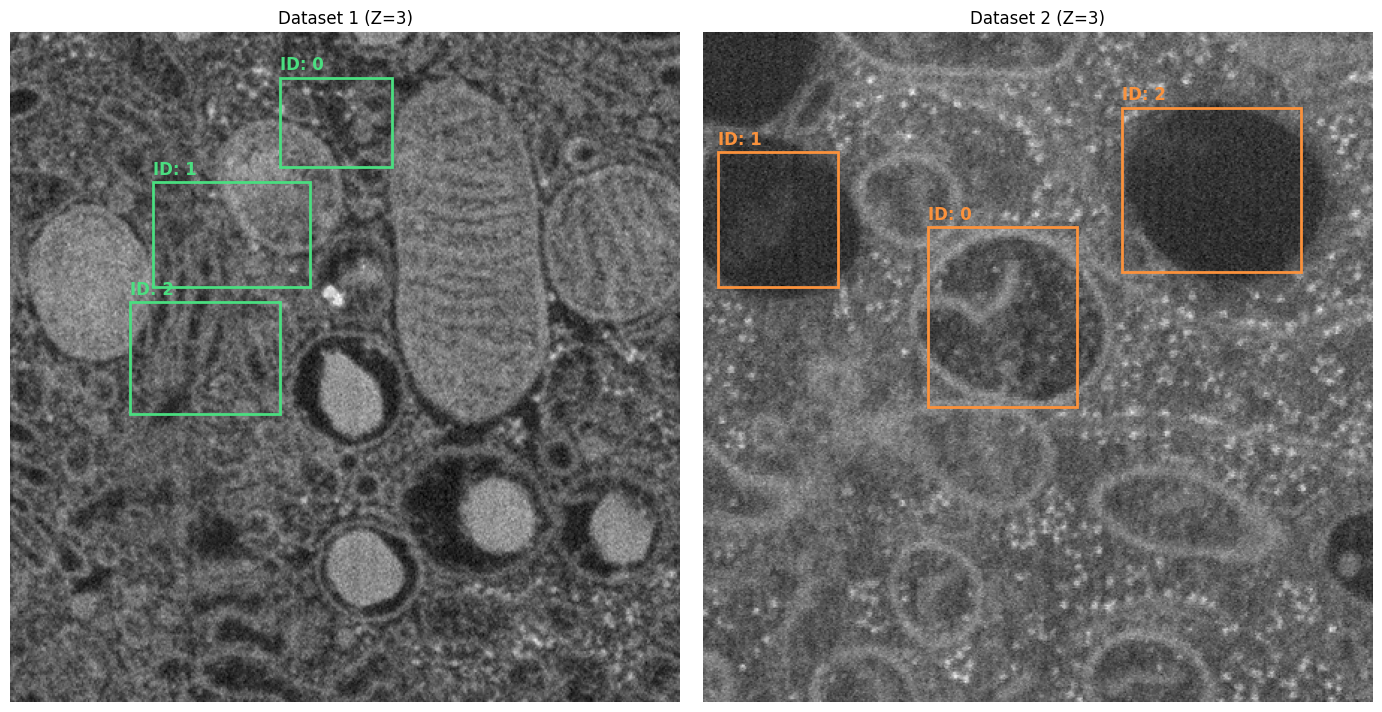

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Your box data
mito_boxes_ds1 = [
    {'id': 0, 'z': 3, 'y_min': 30, 'y_max': 90, 'x_min': 180, 'x_max': 255},
    {'id': 1, 'z': 3, 'y_min': 100, 'y_max': 170, 'x_min': 95, 'x_max': 200},
    {'id': 2, 'z': 3, 'y_min': 180, 'y_max': 255, 'x_min': 80,  'x_max': 180},
]

mito_boxes_ds2 = [
    {'id': 0, 'z': 3, 'y_min': 130, 'y_max': 250, 'x_min': 150, 'x_max': 250},
    {'id': 1, 'z': 3, 'y_min': 80,  'y_max': 170, 'x_min': 10, 'x_max': 90},
    {'id': 2, 'z': 3, 'y_min': 50, 'y_max': 160, 'x_min': 280,  'x_max': 400},

]

def plot_boxes_side_by_side(z_slice, raw_a, raw_b, boxes_1, boxes_2):
    """
    Plots the raw image slices side-by-side and draws boxes ONLY if they 
    belong to the current Z-slice.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # --- Dataset 1 Plot (Left Side) ---
    axes[0].imshow(raw_a[z_slice], cmap='gray')
    axes[0].set_title(f"Dataset 1 (Z={z_slice})")
    axes[0].axis('off')
    
    # Loop through the first list of boxes
    for box in boxes_1:
        if box['z'] == z_slice:
            # Calculate width and height
            w = box['x_max'] - box['x_min']
            h = box['y_max'] - box['y_min']
            
            # Draw the box (Neon Green)
            rect = mpatches.Rectangle(
                (box['x_min'], box['y_min']), w, h, 
                linewidth=2, edgecolor='#4ade80', facecolor='none'
            )
            axes[0].add_patch(rect)
            # Add a small text label for the ID
            axes[0].text(box['x_min'], box['y_min']-5, f"ID: {box['id']}", 
                         color='#4ade80', fontsize=12, fontweight='bold')

    # --- Dataset 2 Plot (Right Side) ---
    axes[1].imshow(raw_b[z_slice], cmap='gray')
    axes[1].set_title(f"Dataset 2 (Z={z_slice})")
    axes[1].axis('off')
    
    # Loop through the second list of boxes
    for box in boxes_2:
        if box['z'] == z_slice:
            # Calculate width and height
            w = box['x_max'] - box['x_min']
            h = box['y_max'] - box['y_min']
            
            # Draw the box (Neon Orange)
            rect = mpatches.Rectangle(
                (box['x_min'], box['y_min']), w, h, 
                linewidth=2, edgecolor='#fb923c', facecolor='none'
            )
            axes[1].add_patch(rect)
            axes[1].text(box['x_min'], box['y_min']-5, f"ID: {box['id']}", 
                         color='#fb923c', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- Execution ---
# Let's look at Z-slice 3 (where ID 1 lives)
# Assuming raw_a and raw_b are already loaded from your previous steps
raw_path_5='artifacts/data_ingestion/ps1.npy'
raw5 = np.load(raw_path_5)
raw6=np.load('artifacts/data_ingestion/ts0.npy')
plot_boxes_side_by_side(z_slice=3, raw_a=raw5, raw_b=raw6, boxes_1=mito_boxes_ds1, boxes_2=mito_boxes_ds2)

# Try Z-slice 2 to see ID 0!
# plot_boxes_side_by_side(z_slice=2, raw_a=raw_a, raw_b=raw_b, boxes_1=mito_boxes_ds1, boxes_2=mito_boxes_ds2)

In [9]:
n_samples= 5000
idx1 = np.random.choice(len(flat1), n_samples, replace=False)
idx2 = np.random.choice(len(flat2), n_samples, replace=False)
X = flat1[idx1]
Y = flat2[idx2]

dists = np.sum((X[:100, None] - Y[None, :100]) ** 2, axis=-1)
sigma = np.median(dists) + 1e-8

def rbf(A, B):
    d = np.sum((A[:, None] - B[None]) ** 2, axis=-1)
    return np.exp(-d / (2 * sigma))

mmd=float(rbf(X, X).mean() + rbf(Y, Y).mean() - 2 * rbf(X, Y).mean())
print(f'mmd: {mmd}')

mmd: 0.06640625


In [16]:
from sklearn.decomposition import PCA

In [21]:
def align(query_vec, gallery):
    mu1  = flat1.mean(axis=0, keepdims=True)
    std1 = flat1.std(axis=0,  keepdims=True) + 1e-8
    mu2  = flat2.mean(axis=0, keepdims=True)
    std2 = flat2.std(axis=0,  keepdims=True) + 1e-8

    q_aligned = normalize((query_vec - mu1) / std1, norm='l2')
    g_aligned = normalize((gallery   - mu2) / std2, norm='l2')

    return q_aligned, g_aligned

def get_query_vector(dataset, z, y_min, y_max, x_min, x_max):
    emb = emb1 if dataset == 1 else emb2
    roi = emb[:, z, y_min:y_max, x_min:x_max]
    vec = roi.mean(axis=(1, 2))
    vec = vec / (np.linalg.norm(vec) + 1e-8)
    return vec.reshape(1, -1)

def compute_cross_heatmap(query_vec, use_alignment=True):
    if use_alignment:
        q, gallery = align(query_vec, flat2)
    else:
        q, gallery = normalize(query_vec, norm='l2'), flat2

    sim = (gallery @ q.T).squeeze()
    return sim.reshape(z2, h2, w2)

def _project_pca(vecs_list, use_alignment):
    if use_alignment:
        mu1  = flat1.mean(0); std1 = flat1.std(0) + 1e-8
        mu2  = flat2.mean(0); std2 = flat2.std(0) + 1e-8
        aligned = []
        for i, v in enumerate(vecs_list):
            mu  = mu1  if i % 2 == 0 else mu2
            std = std1 if i % 2 == 0 else std2
            aligned.append(normalize((v - mu) / std, norm='l2'))
        vecs_list = aligned

    all_vecs = np.vstack(vecs_list)
    pca      = PCA(n_components=2)
    proj     = pca.fit_transform(all_vecs)
    var      = pca.explained_variance_ratio_

    sizes   = [len(v) for v in vecs_list]
    splits  = np.cumsum(sizes[:-1])
    parts   = np.split(proj, splits)
    return parts, var


In [19]:
#ls0
mito_boxes_ds1 = [
    {'id': 0, 'z': 3, 'y_min': 320, 'y_max': 400, 'x_min': 290, 'x_max': 390},
    {'id': 1, 'z': 3, 'y_min': 90, 'y_max': 185, 'x_min': 250, 'x_max': 350},
    {'id': 2, 'z': 3, 'y_min': 200, 'y_max': 290, 'x_min': 90,  'x_max': 200},
]
#ls1
mito_boxes_ds2 = [
    {'id': 0, 'z': 3, 'y_min': 60, 'y_max': 140, 'x_min': 170, 'x_max': 250},
    {'id': 1, 'z': 3, 'y_min': 90,  'y_max': 155, 'x_min': 300, 'x_max': 390},
    {'id': 2, 'z': 3, 'y_min': 320, 'y_max': 398, 'x_min': 300,  'x_max': 395},
]
#hs0
mito_boxes_ds3 = [
    {'id': 0, 'z': 3, 'y_min': 30, 'y_max': 90, 'x_min': 180, 'x_max': 255},
    {'id': 1, 'z': 3, 'y_min': 100, 'y_max': 170, 'x_min': 95, 'x_max': 200},
    {'id': 2, 'z': 3, 'y_min': 180, 'y_max': 255, 'x_min': 80,  'x_max': 180},
]
#hs1
mito_boxes_ds4 = [
    {'id': 0, 'z': 3, 'y_min': 6, 'y_max': 40, 'x_min': 170, 'x_max': 250},
    {'id': 1, 'z': 3, 'y_min': 6,  'y_max': 40, 'x_min': 100, 'x_max': 140},
    {'id': 2, 'z': 3, 'y_min': 8, 'y_max': 45, 'x_min': 30,  'x_max': 75},
]
#ps1
mito_boxes_ds5 = [
    {'id': 0, 'z': 3, 'y_min': 20, 'y_max': 200, 'x_min': 240, 'x_max': 350},
    {'id': 1, 'z': 3, 'y_min': 110,  'y_max': 200, 'x_min': 20, 'x_max': 100},
    {'id': 2, 'z': 3, 'y_min': 80, 'y_max': 210, 'x_min': 365,  'x_max': 440},

]

/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


Saved → artifacts/retri_viz/cross_pca.png


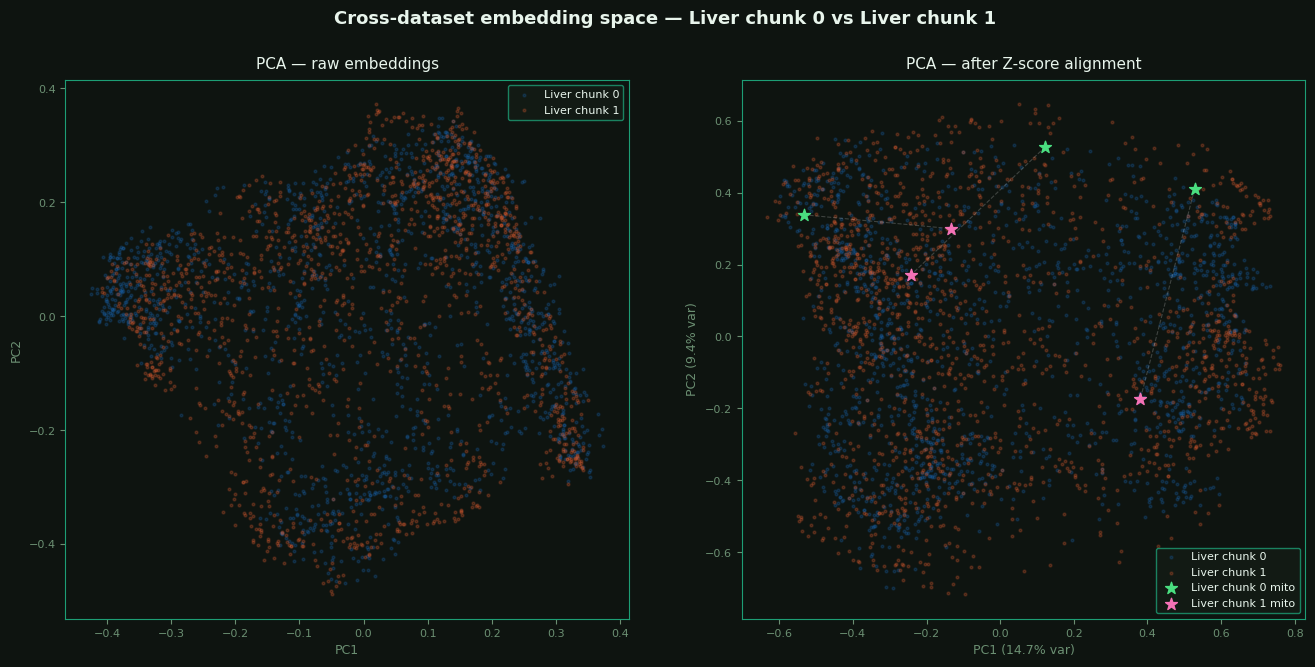

In [157]:

def plot_embedding_space(
    mito_boxes_1, mito_boxes_2,
    n_background=1500,
    use_alignment=True,
    save_path=None,
):
    idx1 = np.random.choice(len(flat1), n_background, replace=False)
    idx2 = np.random.choice(len(flat2), n_background, replace=False)
    bg1  = flat1[idx1]
    bg2  = flat2[idx2]

    mito1 = np.vstack([
        get_query_vector(1, b['z'], b['y_min'], b['y_max'],
                                b['x_min'], b['x_max'])
        for b in mito_boxes_1
    ])
    mito2 = np.vstack([
        get_query_vector(2, b['z'], b['y_min'], b['y_max'],
                                b['x_min'], b['x_max'])
        for b in mito_boxes_2
    ])

    (p_bg1, p_bg2, p_m1, p_m2), var = _project_pca(
        [bg1, bg2, mito1, mito2], use_alignment
    )

    idx1r = np.random.choice(len(flat1), n_background, replace=False)
    idx2r = np.random.choice(len(flat2), n_background, replace=False)
    raw_proj = PCA(n_components=2).fit_transform(
        np.vstack([flat1[idx1r], flat2[idx2r]])
    )
    rp_bg1 = raw_proj[:n_background]
    rp_bg2 = raw_proj[n_background:]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor('#0e1410')

    for ax_idx, ax in enumerate(axes):
        ax.set_facecolor('#0e1410')
        if ax_idx == 0:
            ax.scatter(rp_bg1[:,0], rp_bg1[:,1],
                        c='#185FA5', alpha=0.25, s=4, label=label_1)
            ax.scatter(rp_bg2[:,0], rp_bg2[:,1],
                        c='#D85A30', alpha=0.25, s=4, label=label_2)
            ax.set_title('PCA — raw embeddings',
                            color='#e8f5ec', fontsize=11, pad=8)
            ax.set_xlabel('PC1', color='#6b8f72', fontsize=9)
            ax.set_ylabel('PC2', color='#6b8f72', fontsize=9)
        else:
            ax.scatter(p_bg1[:,0], p_bg1[:,1],
                        c='#185FA5', alpha=0.25, s=4, label=label_1)
            ax.scatter(p_bg2[:,0], p_bg2[:,1],
                        c='#D85A30', alpha=0.25, s=4, label=label_2)
            ax.scatter(p_m1[:,0],  p_m1[:,1],
                        c='#4ade80', s=80, marker='*', zorder=5,
                        label=f'{label_1} mito')
            ax.scatter(p_m2[:,0],  p_m2[:,1],
                        c='#f472b6', s=80, marker='*', zorder=5,
                        label=f'{label_2} mito')
            for m1v, m2v in zip(p_m1, p_m2):
                ax.plot([m1v[0], m2v[0]], [m1v[1], m2v[1]],
                        color='white', alpha=0.2, linewidth=0.8,
                        linestyle='--')
            ax.set_title('PCA — after Z-score alignment',
                            color='#e8f5ec', fontsize=11, pad=8)
            ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var)',
                            color='#6b8f72', fontsize=9)
            ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var)',
                            color='#6b8f72', fontsize=9)

        ax.tick_params(colors='#6b8f72', labelsize=8)
        for sp in ax.spines.values():
            sp.set_edgecolor('#1D9E75')
        ax.legend(fontsize=8, facecolor='#141c16',
                    edgecolor='#1D9E75', labelcolor='#e8f5ec')

    fig.suptitle(
        f'Cross-dataset embedding space — {label_1} vs {label_2}',
        color='#e8f5ec', fontsize=13, fontweight='bold',
    )

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f'Saved → {save_path}')
    plt.show()

plot_embedding_space(
    mito_boxes_ds3, mito_boxes_ds4,
    n_background=1500,
    save_path='artifacts/retri_viz/cross_pca.png',
)

In [158]:
import matplotlib.gridspec as gridspec
def plot_cross_retrieval(

    query_box,
    z_slice_2,
    threshold,
    use_alignment=True,
    save_path=None,
):
    query_vec = get_query_vector(
        1,
        query_box['z'],
        query_box['y_min'], query_box['y_max'],
        query_box['x_min'], query_box['x_max'],
    )
    sim_map = compute_cross_heatmap(query_vec, use_alignment)
    heatmap = sim_map[z_slice_2]
    # threshold = np.percentile(heatmap, 98.5)
    masked  = np.ma.masked_where(heatmap < threshold, heatmap)

    fig = plt.figure(figsize=(18, 6))
    fig.patch.set_facecolor('#0e1410')
    gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.1,
                            left=0.03, right=0.97)

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(raw1[query_box['z']], cmap='gray')
    ax0.add_patch(mpatches.Rectangle(
        (query_box['x_min'], query_box['y_min']),
        query_box['x_max'] - query_box['x_min'],
        query_box['y_max'] - query_box['y_min'],
        linewidth=2, edgecolor='#4ade80', facecolor='none',
    ))
    ax0.set_title(f'Query [{label_1}]  z={query_box["z"]}',
                    color='#4ade80', fontsize=10, pad=6)

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(raw2[z_slice_2], cmap='gray')
    ax1.set_title(f'Target [{label_2}]  z={z_slice_2}',
                    color='#e8f5ec', fontsize=10, pad=6)

    ax2 = fig.add_subplot(gs[2])
    ax2.imshow(raw2[z_slice_2], cmap='gray')
    im2 = ax2.imshow(masked, cmap='hot', alpha=0.65,
                        vmin=threshold, vmax=1.0)
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04,
                    label='Cosine similarity')
    ax2.set_title(f'Cross-dataset overlay  (threshold={threshold})',
                    color='#e8f5ec', fontsize=10, pad=6)

    ax3 = fig.add_subplot(gs[3])
    ax3.set_facecolor('#141c16')
    ax3.hist(heatmap.flatten(), bins=60,
                color='#D85A30', edgecolor='#0e1410', linewidth=0.4)
    ax3.axvline(threshold, color='#4ade80', linewidth=1.5,
                label=f'threshold={threshold}')
    ax3.axvline(heatmap.mean(), color='#f472b6', linewidth=1.2,
                linestyle='--', label=f'mean={heatmap.mean():.3f}')
    ax3.set_xlabel('Cosine similarity', color='#6b8f72', fontsize=9)
    ax3.set_ylabel('Pixel count',       color='#6b8f72', fontsize=9)
    ax3.tick_params(colors='#6b8f72', labelsize=8)
    for sp in ax3.spines.values():
        sp.set_edgecolor('#1D9E75')
    ax3.legend(fontsize=8, labelcolor='#e8f5ec',
                facecolor='#0e1410', edgecolor='#1D9E75')

    for ax in [ax0, ax1, ax2]:
        ax.axis('off')

    fig.suptitle(
        f'Cross-dataset retrieval — {label_1} → {label_2}',
        color='#e8f5ec', fontsize=13, fontweight='bold', y=1.02,
    )

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f'Saved → {save_path}')
    plt.show()


/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


Saved → artifacts/retri_viz/cross_overlay_z28.png


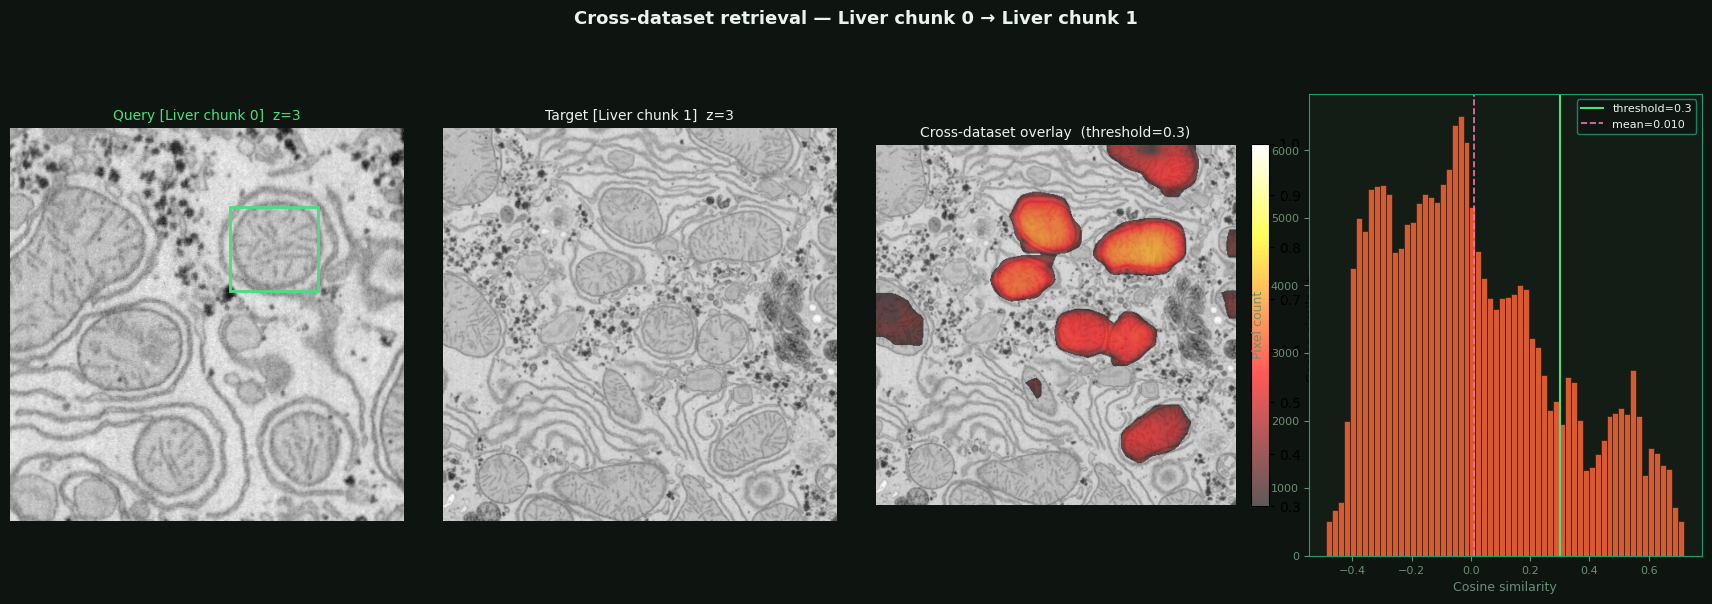

In [95]:

plot_cross_retrieval(
    query_box  = mito_boxes_ds3[1],
    z_slice_2  = 3,threshold=0.3,
    save_path  = 'artifacts/retri_viz/cross_overlay_z28.png',
)

In [22]:

def mutual_nn_rate(mito_boxes_1, mito_boxes_2, use_alignment=True):
        vecs1 = np.vstack([
            get_query_vector(1, b['z'], b['y_min'], b['y_max'],
                                  b['x_min'], b['x_max'])
            for b in mito_boxes_1
        ])
        vecs2 = np.vstack([
            get_query_vector(2, b['z'], b['y_min'], b['y_max'],
                                  b['x_min'], b['x_max'])
            for b in mito_boxes_2
        ])

        if use_alignment:
            mu1  = flat1.mean(0); std1 = flat1.std(0) + 1e-8
            mu2  = flat2.mean(0); std2 = flat2.std(0) + 1e-8
            vecs1 = normalize((vecs1 - mu1) / std1, norm='l2')
            vecs2 = normalize((vecs2 - mu2) / std2, norm='l2')

        sim_12 = vecs1 @ vecs2.T
        nn_12  = sim_12.argmax(axis=1)

        sim_21 = vecs2 @ vecs1.T
        nn_21  = sim_21.argmax(axis=1)

        matches = []
        for i, j in enumerate(nn_12):
            matches.append({
                'ds1_id'  : mito_boxes_1[i]['id'],
                'ds2_id'  : mito_boxes_2[j]['id'],
                'sim'     : float(sim_12[i, j]),
                'mutual'  : bool(nn_21[j] == i),
            })

        mnn_rate = sum(m['mutual'] for m in matches) / len(matches)

        print(f'\n[MNN] Mutual nearest-neighbour rate : {mnn_rate:.3f}')
        print(f'{"DS1 ID":<10} {"DS2 ID":<10} {"Sim":>8} {"MNN":>6}')
        print('─' * 36)
        for m in matches:
            print(f'{m["ds1_id"]:<10} {m["ds2_id"]:<10} '
                  f'{m["sim"]:>8.4f} {"YES" if m["mutual"] else "—":>6}')

        return {'mnn_rate': mnn_rate, 'matches': matches}

mito_boxes_1=mito_boxes_ds1
mito_boxes_2=mito_boxes_ds2
mutual_nn_rate(mito_boxes_1, mito_boxes_2)

/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)



[MNN] Mutual nearest-neighbour rate : 0.667
DS1 ID     DS2 ID          Sim    MNN
────────────────────────────────────
0          2            0.7603    YES
1          1            0.7036    YES
2          0            0.5254      —


{'mnn_rate': 0.6666666666666666,
 'matches': [{'ds1_id': 0, 'ds2_id': 2, 'sim': 0.76025390625, 'mutual': True},
  {'ds1_id': 1, 'ds2_id': 1, 'sim': 0.70361328125, 'mutual': True},
  {'ds1_id': 2, 'ds2_id': 0, 'sim': 0.525390625, 'mutual': False}]}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


class CrossDatasetRetriever:
    def __init__(
        self,
        emb_path_1: str, raw_path_1: str, label_1: str,
        emb_path_2: str, raw_path_2: str, label_2: str,
    ):
        self.label_1 = label_1
        self.label_2 = label_2
        # emb_a = torch.load(emb_path_a).float()
        # emb_b = torch.load(emb_path_b).float()

        self.emb1 = torch.load(emb_path_1).numpy()
        self.emb2 = torch.load(emb_path_2).numpy()
        self.raw1 = np.load(raw_path_1)
        self.raw2 = np.load(raw_path_2)

        self.c1, self.z1, self.h1, self.w1 = self.emb1.shape
        self.c2, self.z2, self.h2, self.w2 = self.emb2.shape

        self.flat1 = normalize(self.emb1.reshape(self.c1, -1).T, norm='l2')
        self.flat2 = normalize(self.emb2.reshape(self.c2, -1).T, norm='l2')

        print(
            f'[{label_1}] embeddings: {self.emb1.shape} | voxels: {self.flat1.shape}\n'
            f'[{label_2}] embeddings: {self.emb2.shape} | voxels: {self.flat2.shape}'
        )

    def compute_mmd(self, n_samples: int = 5000) -> float:
        idx1 = np.random.choice(len(self.flat1), n_samples, replace=False)
        idx2 = np.random.choice(len(self.flat2), n_samples, replace=False)
        X = self.flat1[idx1]
        Y = self.flat2[idx2]

        dists = np.sum((X[:100, None] - Y[None, :100]) ** 2, axis=-1)
        sigma = np.median(dists) + 1e-8

        def rbf(A, B):
            d = np.sum((A[:, None] - B[None]) ** 2, axis=-1)
            return np.exp(-d / (2 * sigma))

        return float(rbf(X, X).mean() + rbf(Y, Y).mean() - 2 * rbf(X, Y).mean())

    def align(self, query_vec, gallery):
        mu1  = self.flat1.mean(axis=0, keepdims=True)
        std1 = self.flat1.std(axis=0,  keepdims=True) + 1e-8
        mu2  = self.flat2.mean(axis=0, keepdims=True)
        std2 = self.flat2.std(axis=0,  keepdims=True) + 1e-8

        q_aligned = normalize((query_vec - mu1) / std1, norm='l2')
        g_aligned = normalize((gallery   - mu2) / std2, norm='l2')

        return q_aligned, g_aligned

    def get_query_vector(self, dataset, z, y_min, y_max, x_min, x_max):
        emb = self.emb1 if dataset == 1 else self.emb2
        roi = emb[:, z, y_min:y_max, x_min:x_max]
        vec = roi.mean(axis=(1, 2))
        vec = vec / (np.linalg.norm(vec) + 1e-8)
        return vec.reshape(1, -1)

    def compute_cross_heatmap(self, query_vec, use_alignment=True):
        if use_alignment:
            q, gallery = self.align(query_vec, self.flat2)
        else:
            q, gallery = normalize(query_vec, norm='l2'), self.flat2

        sim = (gallery @ q.T).squeeze()
        return sim.reshape(self.z2, self.h2, self.w2)

    def mutual_nn_rate(self, mito_boxes_1, mito_boxes_2, use_alignment=True):
        vecs1 = np.vstack([
            self.get_query_vector(1, b['z'], b['y_min'], b['y_max'],
                                  b['x_min'], b['x_max'])
            for b in mito_boxes_1
        ])
        vecs2 = np.vstack([
            self.get_query_vector(2, b['z'], b['y_min'], b['y_max'],
                                  b['x_min'], b['x_max'])
            for b in mito_boxes_2
        ])

        if use_alignment:
            mu1  = self.flat1.mean(0); std1 = self.flat1.std(0) + 1e-8
            mu2  = self.flat2.mean(0); std2 = self.flat2.std(0) + 1e-8
            vecs1 = normalize((vecs1 - mu1) / std1, norm='l2')
            vecs2 = normalize((vecs2 - mu2) / std2, norm='l2')

        sim_12 = vecs1 @ vecs2.T
        nn_12  = sim_12.argmax(axis=1)

        sim_21 = vecs2 @ vecs1.T
        nn_21  = sim_21.argmax(axis=1)

        matches = []
        for i, j in enumerate(nn_12):
            matches.append({
                'ds1_id'  : mito_boxes_1[i]['id'],
                'ds2_id'  : mito_boxes_2[j]['id'],
                'sim'     : float(sim_12[i, j]),
                'mutual'  : bool(nn_21[j] == i),
            })

        mnn_rate = sum(m['mutual'] for m in matches) / len(matches)

        print(f'\n[MNN] Mutual nearest-neighbour rate : {mnn_rate:.3f}')
        print(f'{"DS1 ID":<10} {"DS2 ID":<10} {"Sim":>8} {"MNN":>6}')
        print('─' * 36)
        for m in matches:
            print(f'{m["ds1_id"]:<10} {m["ds2_id"]:<10} '
                  f'{m["sim"]:>8.4f} {"YES" if m["mutual"] else "—":>6}')

        return {'mnn_rate': mnn_rate, 'matches': matches}

    def _project_pca(self, vecs_list, use_alignment):
        if use_alignment:
            mu1  = self.flat1.mean(0); std1 = self.flat1.std(0) + 1e-8
            mu2  = self.flat2.mean(0); std2 = self.flat2.std(0) + 1e-8
            aligned = []
            for i, v in enumerate(vecs_list):
                mu  = mu1  if i % 2 == 0 else mu2
                std = std1 if i % 2 == 0 else std2
                aligned.append(normalize((v - mu) / std, norm='l2'))
            vecs_list = aligned

        all_vecs = np.vstack(vecs_list)
        pca      = PCA(n_components=2)
        proj     = pca.fit_transform(all_vecs)
        var      = pca.explained_variance_ratio_

        sizes   = [len(v) for v in vecs_list]
        splits  = np.cumsum(sizes[:-1])
        parts   = np.split(proj, splits)
        return parts, var

    def plot_embedding_space(
        self,
        mito_boxes_1, mito_boxes_2,
        n_background=1500,
        use_alignment=True,
        save_path=None,
    ):
        idx1 = np.random.choice(len(self.flat1), n_background, replace=False)
        idx2 = np.random.choice(len(self.flat2), n_background, replace=False)
        bg1  = self.flat1[idx1]
        bg2  = self.flat2[idx2]

        mito1 = np.vstack([
            self.get_query_vector(1, b['z'], b['y_min'], b['y_max'],
                                  b['x_min'], b['x_max'])
            for b in mito_boxes_1
        ])
        mito2 = np.vstack([
            self.get_query_vector(2, b['z'], b['y_min'], b['y_max'],
                                  b['x_min'], b['x_max'])
            for b in mito_boxes_2
        ])

        (p_bg1, p_bg2, p_m1, p_m2), var = self._project_pca(
            [bg1, bg2, mito1, mito2], use_alignment
        )

        idx1r = np.random.choice(len(self.flat1), n_background, replace=False)
        idx2r = np.random.choice(len(self.flat2), n_background, replace=False)
        raw_proj = PCA(n_components=2).fit_transform(
            np.vstack([self.flat1[idx1r], self.flat2[idx2r]])
        )
        rp_bg1 = raw_proj[:n_background]
        rp_bg2 = raw_proj[n_background:]

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.patch.set_facecolor('#0e1410')

        for ax_idx, ax in enumerate(axes):
            ax.set_facecolor('#0e1410')
            if ax_idx == 0:
                ax.scatter(rp_bg1[:,0], rp_bg1[:,1],
                           c='#185FA5', alpha=0.25, s=4, label=self.label_1)
                ax.scatter(rp_bg2[:,0], rp_bg2[:,1],
                           c='#D85A30', alpha=0.25, s=4, label=self.label_2)
                ax.set_title('PCA — raw embeddings',
                             color='#e8f5ec', fontsize=11, pad=8)
                ax.set_xlabel('PC1', color='#6b8f72', fontsize=9)
                ax.set_ylabel('PC2', color='#6b8f72', fontsize=9)
            else:
                ax.scatter(p_bg1[:,0], p_bg1[:,1],
                           c='#185FA5', alpha=0.25, s=4, label=self.label_1)
                ax.scatter(p_bg2[:,0], p_bg2[:,1],
                           c='#D85A30', alpha=0.25, s=4, label=self.label_2)
                ax.scatter(p_m1[:,0],  p_m1[:,1],
                           c='#4ade80', s=80, marker='*', zorder=5,
                           label=f'{self.label_1} mito')
                ax.scatter(p_m2[:,0],  p_m2[:,1],
                           c='#f472b6', s=80, marker='*', zorder=5,
                           label=f'{self.label_2} mito')
                for m1v, m2v in zip(p_m1, p_m2):
                    ax.plot([m1v[0], m2v[0]], [m1v[1], m2v[1]],
                            color='white', alpha=0.2, linewidth=0.8,
                            linestyle='--')
                ax.set_title('PCA — after Z-score alignment',
                             color='#e8f5ec', fontsize=11, pad=8)
                ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var)',
                              color='#6b8f72', fontsize=9)
                ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var)',
                              color='#6b8f72', fontsize=9)

            ax.tick_params(colors='#6b8f72', labelsize=8)
            for sp in ax.spines.values():
                sp.set_edgecolor('#1D9E75')
            ax.legend(fontsize=8, facecolor='#141c16',
                      edgecolor='#1D9E75', labelcolor='#e8f5ec')

        fig.suptitle(
            f'Cross-dataset embedding space — {self.label_1} vs {self.label_2}',
            color='#e8f5ec', fontsize=13, fontweight='bold',
        )

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
            print(f'Saved → {save_path}')
        plt.show()

    def plot_cross_retrieval(
        self,
        query_box,
        z_slice_2,
        threshold=0.65,
        use_alignment=True,
        save_path=None,
    ):
        query_vec = self.get_query_vector(
            1,
            query_box['z'],
            query_box['y_min'], query_box['y_max'],
            query_box['x_min'], query_box['x_max'],
        )
        sim_map = self.compute_cross_heatmap(query_vec, use_alignment)
        heatmap = sim_map[z_slice_2]
        masked  = np.ma.masked_where(heatmap < threshold, heatmap)

        fig = plt.figure(figsize=(18, 6))
        fig.patch.set_facecolor('#0e1410')
        gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.1,
                                left=0.03, right=0.97)

        ax0 = fig.add_subplot(gs[0])
        ax0.imshow(self.raw1[query_box['z']], cmap='gray')
        ax0.add_patch(mpatches.Rectangle(
            (query_box['x_min'], query_box['y_min']),
            query_box['x_max'] - query_box['x_min'],
            query_box['y_max'] - query_box['y_min'],
            linewidth=2, edgecolor='#4ade80', facecolor='none',
        ))
        ax0.set_title(f'Query [{self.label_1}]  z={query_box["z"]}',
                      color='#4ade80', fontsize=10, pad=6)

        ax1 = fig.add_subplot(gs[1])
        ax1.imshow(self.raw2[z_slice_2], cmap='gray')
        ax1.set_title(f'Target [{self.label_2}]  z={z_slice_2}',
                      color='#e8f5ec', fontsize=10, pad=6)

        ax2 = fig.add_subplot(gs[2])
        ax2.imshow(self.raw2[z_slice_2], cmap='gray')
        im2 = ax2.imshow(masked, cmap='hot', alpha=0.65,
                         vmin=threshold, vmax=1.0)
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04,
                     label='Cosine similarity')
        ax2.set_title(f'Cross-dataset overlay  (threshold={threshold})',
                      color='#e8f5ec', fontsize=10, pad=6)

        ax3 = fig.add_subplot(gs[3])
        ax3.set_facecolor('#141c16')
        ax3.hist(heatmap.flatten(), bins=60,
                 color='#D85A30', edgecolor='#0e1410', linewidth=0.4)
        ax3.axvline(threshold, color='#4ade80', linewidth=1.5,
                    label=f'threshold={threshold}')
        ax3.axvline(heatmap.mean(), color='#f472b6', linewidth=1.2,
                    linestyle='--', label=f'mean={heatmap.mean():.3f}')
        ax3.set_xlabel('Cosine similarity', color='#6b8f72', fontsize=9)
        ax3.set_ylabel('Pixel count',       color='#6b8f72', fontsize=9)
        ax3.tick_params(colors='#6b8f72', labelsize=8)
        for sp in ax3.spines.values():
            sp.set_edgecolor('#1D9E75')
        ax3.legend(fontsize=8, labelcolor='#e8f5ec',
                   facecolor='#0e1410', edgecolor='#1D9E75')

        for ax in [ax0, ax1, ax2]:
            ax.axis('off')

        fig.suptitle(
            f'Cross-dataset retrieval — {self.label_1} → {self.label_2}',
            color='#e8f5ec', fontsize=13, fontweight='bold', y=1.02,
        )

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
            print(f'Saved → {save_path}')
        plt.show()


# ── Usage ──────────────────────────────────────────────────────────────────────

retriever = CrossDatasetRetriever(
    emb_path_1='artifacts/models/ls0.pt',
    raw_path_1='artifacts/data_ingestion/ls0.npy',
    label_1='Liver chunk 0',
    emb_path_2='artifacts/models/ls1.pt',
    raw_path_2='artifacts/data_ingestion/ls1.npy',
    label_2='Liver chunk 1',
)

mmd = retriever.compute_mmd(n_samples=5000)
print(f'MMD score : {mmd:.6f}')

mito_boxes_ds1 = [
    {'id': 0, 'z': 2, 'y_min': 192, 'y_max': 240, 'x_min': 192, 'x_max': 240},
    {'id': 1, 'z': 3, 'y_min': 100, 'y_max': 145, 'x_min': 300, 'x_max': 350},
    {'id': 2, 'z': 1, 'y_min': 310, 'y_max': 355, 'x_min': 80,  'x_max': 130},
]
mito_boxes_ds2 = [
    {'id': 0, 'z': 2, 'y_min': 200, 'y_max': 248, 'x_min': 180, 'x_max': 228},
    {'id': 1, 'z': 3, 'y_min': 90,  'y_max': 135, 'x_min': 310, 'x_max': 358},
    {'id': 2, 'z': 2, 'y_min': 320, 'y_max': 365, 'x_min': 70,  'x_max': 118},
]

mnn_results = retriever.mutual_nn_rate(mito_boxes_ds1, mito_boxes_ds2)

retriever.plot_embedding_space(
    mito_boxes_ds1, mito_boxes_ds2,
    n_background=1500,
    save_path='artifacts/retrieval/cross_pca.png',
)

retriever.plot_cross_retrieval(
    query_box  = mito_boxes_ds1[0],
    z_slice_2  = 28,
    threshold  = 0.65,
    save_path  = 'artifacts/retrieval/cross_overlay_z28.png',
)

[Liver chunk 0] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)
[Liver chunk 1] embeddings: (384, 6, 448, 448) | voxels: (1204224, 384)
